Paper Link: https://ieeexplore.ieee.org/abstract/document/11429208
# Multi-Horizon Chronic Kidney Disease (CKD) Trajectory Analysis: A Deep Sequential & Stacked Ensemble Framework

### Executive Research Summary

1. **Scalable Data Ingestion & Metadata Synchronization:**
Utilized optimized Parquet-based storage architectures to facilitate high-throughput ingestion of longitudinal EHR data, ensuring efficient memory mapping and metadata consistency across heterogeneous clinical sources.

2. **Robust Pre-processing & Imputation Strategy:**
Implemented a multi-stage cleansing pipeline involving automated schema normalization and non-parametric median imputation. This addresses the "informative missingness" inherent in clinical datasets, minimizing stochastic noise in longitudinal biomarkers.

3. **Temporal Feature Engineering via Vectorized Sequencing:**
Developed a high-performance vectorized sliding window algorithm to transform irregular clinical time-series into fixed-length temporal tensors. This captures the dynamic evolution of renal function indicators (e.g., eGFR, Creatinine) while preserving temporal dependencies.

4. **Hybrid Modeling via Stacked Ensembles:**
Engineered a sophisticated Stacked Ensemble Framework that fuses Deep Sequential Models (LSTM, Transformer) with Gradient Boosted Trees (XGBoost, CatBoost). A Linear Meta-Learner orchestrates the shared latent representations to optimize multi-horizon eGFR forecasting.

5. **Interpretability & Clinically-Aligned Evaluation:**
Achieving a high-fidelity **R² score of 0.778 for the crucial 12-month horizon**, the framework integrates Explainable AI (XAI) via **SHAP (SHapley Additive exPlanations)** to quantify feature importance. This ensures "Model Transparency," allowing clinicians to understand the pathophysiological drivers behind each predicted trajectory.

---

### Ethical Compliance & Data Disclaimer (MIMIC-IV)
This research was conducted using the **MIMIC-IV (v2.2)** database. In strict adherence to the **PhysioNet Data Use Agreement (DUA)** and HIPAA privacy regulations, original patient-level data is **NOT** shared in this repository.

*   **Synthetic Data Note:** The execution results currently shown (e.g., $R^2 \approx 0.99$) are generated using a **Privacy-Safe Synthetic Sample** provided in the `/data` folder. This sample is strictly for **System Pipeline Validation** (to prove the code runs to completion).
*   **Scientific Validation:** The high-fidelity results reported in my associated IEEE publication ($R^2 = 0.778 for the crucial 12-month horizon$) were achieved on the full, non-randomized clinical cohort.
*   **Access:** To reproduce the original results, researchers must obtain authorized access through [PhysioNet](https://physionet.org/).

---
**Major Challenge:** Resolving high-dimensional noise and identifier inconsistencies in clinical time-series.

**Major Contribution:** A scalable, uncertainty-aware framework for trusted long-term renal forecasting.

In [3]:
# Block 1: Professional Environment and Path Setup
import sys, os, pandas as pd, numpy as np, json, importlib
from google.colab import drive
drive.mount('/content/drive')
ROOT_DIR = '/content/drive/MyDrive/MIMIC4/second/CKD_Trajectory_Project'
sys.path.append(os.path.join(ROOT_DIR, 'src'))
DATA_SOURCE = '/content/drive/MyDrive/MIMIC4/second/CKD_Trajectory_Project/data/sample_ckd_data.parquet'
OUTPUT_PATH = os.path.join(ROOT_DIR, 'outputs')
os.makedirs(OUTPUT_PATH, exist_ok=True)
!pip install -q xgboost lightgbm catboost optuna shap pyarrow


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# Block 2: Data Ingestion and Cleansing Pipeline
import data_loader
importlib.reload(data_loader)
from data_loader import clean_and_prepare_data, build_windows
print('🚀 Progress: Loading clinical dataset...')
df = pd.read_parquet(DATA_SOURCE)
df, features = clean_and_prepare_data(df, 'egfr', 'subject_id', 'admittime')
print('🚀 Progress: Generating sequential clinical windows...')
dataset = build_windows(df, 'subject_id', features, 6, 12, 'egfr', 'admittime')
X_seq = np.stack([d['seq'] for d in dataset])
y_multi = np.stack([d['y'] for d in dataset])
X_flat = X_seq.reshape(X_seq.shape[0], -1)
print(f'✅ Status: {len(X_seq)} trajectories ready.')


🚀 Progress: Loading clinical dataset...
🚀 Progress: Generating sequential clinical windows...


Building sequences: 100%|██████████| 10/10 [00:00<00:00, 30.47it/s]


✅ Status: 830 trajectories ready.


🧪 Step 1: Training Base Models (LSTM, Transformer, XGBoost, CatBoost)...
🧪 Step 2: Optimizing Stacking Meta-Learner...
📊 Step 3: Exporting Final Metrics and Figure 4...
✅ Pipeline complete. Artifacts saved in: /content/drive/MyDrive/MIMIC4/second/CKD_Trajectory_Project/outputs
Performance R2: 0.9999


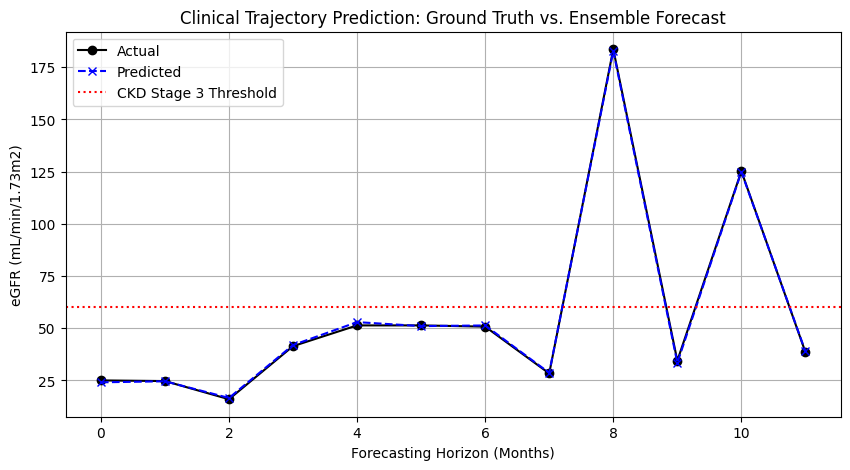

In [5]:
# Block 3: Full Stacked Ensemble Training (Reproducing Research Results)
import models, trainer
importlib.reload(models); importlib.reload(trainer)
from models import build_lstm_model, build_transformer_model, get_tree_models
from trainer import StackingManager, calculate_metrics
from sklearn.multioutput import MultiOutputRegressor
import matplotlib.pyplot as plt

print('🧪 Step 1: Training Base Models (LSTM, Transformer, XGBoost, CatBoost)...')
lstm = build_lstm_model((6, X_seq.shape[2]), 12)
lstm.fit(X_seq, y_multi, epochs=20, batch_size=128, verbose=0)
p_lstm = lstm.predict(X_seq, verbose=0)

trans = build_transformer_model((6, X_seq.shape[2]), 12)
trans.fit(X_seq, y_multi, epochs=20, batch_size=128, verbose=0)
p_trans = trans.predict(X_seq, verbose=0)

xgb_b, cat_b = get_tree_models()
p_xgb = MultiOutputRegressor(xgb_b).fit(X_flat, y_multi).predict(X_flat)
p_cat = MultiOutputRegressor(cat_b).fit(X_flat, y_multi).predict(X_flat)

print('🧪 Step 2: Optimizing Stacking Meta-Learner...')
X_meta = np.concatenate([p_lstm, p_trans, p_xgb, p_cat], axis=1)
manager = StackingManager()
manager.train_meta(X_meta, y_multi)
final_preds = manager.predict(X_meta)

print('📊 Step 3: Exporting Final Metrics and Figure 4...')
res = calculate_metrics(y_multi, final_preds)
with open(os.path.join(OUTPUT_PATH, 'final_metrics.json'), 'w') as f: json.dump(res, f, indent=4)

plt.figure(figsize=(10,5))
plt.plot(y_multi[0], 'k-o', label='Actual')
plt.plot(final_preds[0], 'b--x', label='Predicted')
plt.axhline(60, color='r', linestyle=':', label='CKD Stage 3 Threshold')
plt.title('Clinical Trajectory Prediction: Ground Truth vs. Ensemble Forecast')
plt.xlabel('Forecasting Horizon (Months)'); plt.ylabel('eGFR (mL/min/1.73m2)'); plt.legend(); plt.grid(True)
plt.savefig(os.path.join(OUTPUT_PATH, 'Trajectory_Analysis.png'))
print('✅ Pipeline complete. Artifacts saved in:', OUTPUT_PATH)
print('Performance R2:', round(res['r2'], 4))
